In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

# for path building
from pathlib import Path

In [31]:
# load project modules
from song_recommender.paths import *
from song_recommender.data.indexer import *

# Metadata EDA:

In this notebook, we look at the metadata related to our audio dataset. 

In [32]:
df = pd.read_parquet(DATA_DIR / 'metadata.parquet')
df.sample(5)

,track_id,name,artist,spotify_preview_url,spotify_id,tags,genre,year,duration_ms,danceability,...,tempo,time_signature,crude_genre,duration_min,clip_duration,deezer_name,deezer_artist,isrc,deezer_tags,deezer_year
6887,TROXOMM128F934D01C,On the Sly,Metric,https://p.scdn.co/mp3-preview/e6ee1930178f67d6...,03yQp1w8OBXq7KBXhzg0tB,"indie, female_vocalists, indie_rock, singer_so...",Electronic,2007,238013,0.609,...,131.875,4,rock,3.966883,10.0,On the Sly,Metric,CAL450794005,alternative,2007
710,TRDLKIV128F92F599B,The Whole of the Moon,The Waterboys,https://p.scdn.co/mp3-preview/9781e659a8e0e5da...,0ccrNcOqLDOig0V702RF2n,"rock, classic_rock, 80s",Pop,2012,298400,0.564,...,106.401,4,rock,4.973333,10.0,The Whole of the Moon (2004 Remaster),The Waterboys,GBAYK0400026,rock,1985
4483,TRFSMOA128F42887EE,Steve Biko (Stir It Up),A Tribe Called Quest,https://p.scdn.co/mp3-preview/c2b83814a0086949...,11HkF6A1gNXpTkD2nngZqU,"rap, 90s, hip_hop",Rap,1993,191533,0.816,...,95.203,4,hip_hop,3.192217,10.0,Steve Biko (Stir It Up),A Tribe Called Quest,USJI10300161,rap/hip hop,1993
1486,TRFQZUS128F92F9D98,Lush,Four Tet,https://p.scdn.co/mp3-preview/bde9c24cb59c2f27...,4KjNEsQ4jkqXwCmsn71a9p,"electronic, ambient, house",None,2017,311893,0.659,...,132.907,4,electronic,5.198217,10.0,Lush,Four Tet,GBXNG1746004,electro,2017
8273,TRXHPTU128F9308788,Fadeaway,Porcupine Tree,https://p.scdn.co/mp3-preview/f621a55a6ed5b72c...,0IWlju0jOB1KBxT9J7UcQs,"progressive_rock, psychedelic, psychedelic_rock",None,1993,379493,0.501,...,104.929,4,rock,6.324883,10.0,Burning Sky / Fadeaway,Porcupine Tree,GBCQV1600848,rock,1993


## Feature analysis

**fill this out**

In [33]:
df.columns

Index(['track_id', 'name', 'artist', 'spotify_preview_url', 'spotify_id',
       'tags', 'genre', 'year', 'duration_ms', 'danceability', 'energy', 'key',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'time_signature', 'crude_genre',
       'duration_min', 'clip_duration', 'deezer_name', 'deezer_artist', 'isrc',
       'deezer_tags', 'deezer_year'],
      dtype='object')

## Feature Engineering

We add a `decade` feature.

In [34]:
# add decade feature
df['decade'] = df['year'] - (df['year'] % 10)
df.sample(5)

,track_id,name,artist,spotify_preview_url,spotify_id,tags,genre,year,duration_ms,danceability,...,time_signature,crude_genre,duration_min,clip_duration,deezer_name,deezer_artist,isrc,deezer_tags,deezer_year,decade
2762,TRQRLGR12903CB5C33,Draw Your Swords,Angus & Julia Stone,https://p.scdn.co/mp3-preview/b92a9c08e02ef846...,0nBW63KLXGgpNd2csgdGvY,"folk, chillout, acoustic, piano, beautiful",None,2010,395600,0.686,...,4,folk,6.593333,10.0,Draw Your Swords,Angus & Julia Stone,AUAP10900009,"folk, singer & songwriter",2010,2010
6679,TRGCZVY12903CBFE11,To the Death's Head True,Marduk,https://p.scdn.co/mp3-preview/9c7d57ed86f7492c...,0wP65LpwlYjcoCigqgH8s1,black_metal,None,2005,204480,0.237,...,4,metal,3.408000,10.0,To the Death's Head True,Marduk,SEVCK0200305,"pop, rock, hard rock, metal",2014,2000
2724,TRNSLWT12903D051C8,Thousand Ways,The Tallest Man on Earth,https://p.scdn.co/mp3-preview/f8e62f22a2654945...,10Fl2658AEb8vdEmGroghI,"indie, folk, singer_songwriter, acoustic, beau...",Folk,2010,173413,0.473,...,4,folk,2.890217,10.0,Thousand Ways,The Tallest Man on Earth,USJ5G1034008,"alternative, singer & songwriter",2010,2010
2936,TRALCXK128F932DBE6,Boat Song,Woodkid,https://p.scdn.co/mp3-preview/94f6f0063e4ee0cf...,18Hrbe8UoAoo6euydR45DX,"alternative, indie, folk, beautiful",None,2013,270106,0.404,...,4,folk,4.501767,10.0,Boat Song,Woodkid,FR4DI1200200,alternative,2013,2010
6157,TRYLXLD128EF349B6A,Enuma Elish,Rotting Christ,https://p.scdn.co/mp3-preview/3b771f91fd7b5eae...,17Gi7DAHRLxHuwUd2aJlXt,"black_metal, gothic_metal",None,2009,297000,0.408,...,4,metal,4.950000,10.0,Enuma Elish (Live),Rotting Christ,FR33T1535330,metal,2015,2000


### Task 1: Tag analysis

We accomplish this by string splitting the `tag` column.

In [35]:
# tags need split to identify actual value counts
df['tags'].value_counts()

tags
black_metal                                                       406
rap, hip_hop                                                      272
death_metal                                                       179
death_metal, melodic_death_metal                                  136
punk, punk_rock                                                   126
                                                                 ... 
folk, american                                                      1
rock, classic_rock, folk, 70s, blues_rock                           1
folk, singer_songwriter, acoustic, 70s, male_vocalists, mellow      1
indie, female_vocalists, folk, american, indie_pop, beautiful       1
metalcore, progressive_metal                                        1
Name: count, Length: 5749, dtype: int64

In [36]:
# create tag counter
from collections import Counter

tag_list = []

for index, tags in df['tags'].items():
    tags = tags.replace(' ','')
    tag_list += tags.split(',')

tag_counts = Counter(tag_list)

In [37]:
tag_counts.most_common()

[('rock', 2280),
 ('indie', 1270),
 ('classic_rock', 1171),
 ('folk', 1104),
 ('punk', 1072),
 ('instrumental', 1058),
 ('death_metal', 1054),
 ('electronic', 1025),
 ('80s', 1024),
 ('ambient', 1003),
 ('singer_songwriter', 967),
 ('hip_hop', 951),
 ('alternative', 943),
 ('experimental', 901),
 ('black_metal', 851),
 ('hard_rock', 818),
 ('punk_rock', 767),
 ('70s', 751),
 ('rap', 734),
 ('progressive_rock', 719),
 ('acoustic', 708),
 ('chillout', 681),
 ('indie_rock', 639),
 ('pop', 638),
 ('heavy_metal', 632),
 ('mellow', 629),
 ('metal', 585),
 ('dance', 582),
 ('chill', 564),
 ('melodic_death_metal', 563),
 ('female_vocalists', 562),
 ('alternative_rock', 560),
 ('90s', 553),
 ('00s', 553),
 ('beautiful', 520),
 ('psychedelic', 501),
 ('hardcore', 500),
 ('progressive_metal', 486),
 ('american', 482),
 ('metalcore', 451),
 ('love', 434),
 ('british', 425),
 ('60s', 415),
 ('new_wave', 413),
 ('indie_pop', 410),
 ('piano', 389),
 ('downtempo', 378),
 ('emo', 376),
 ('post_punk', 3

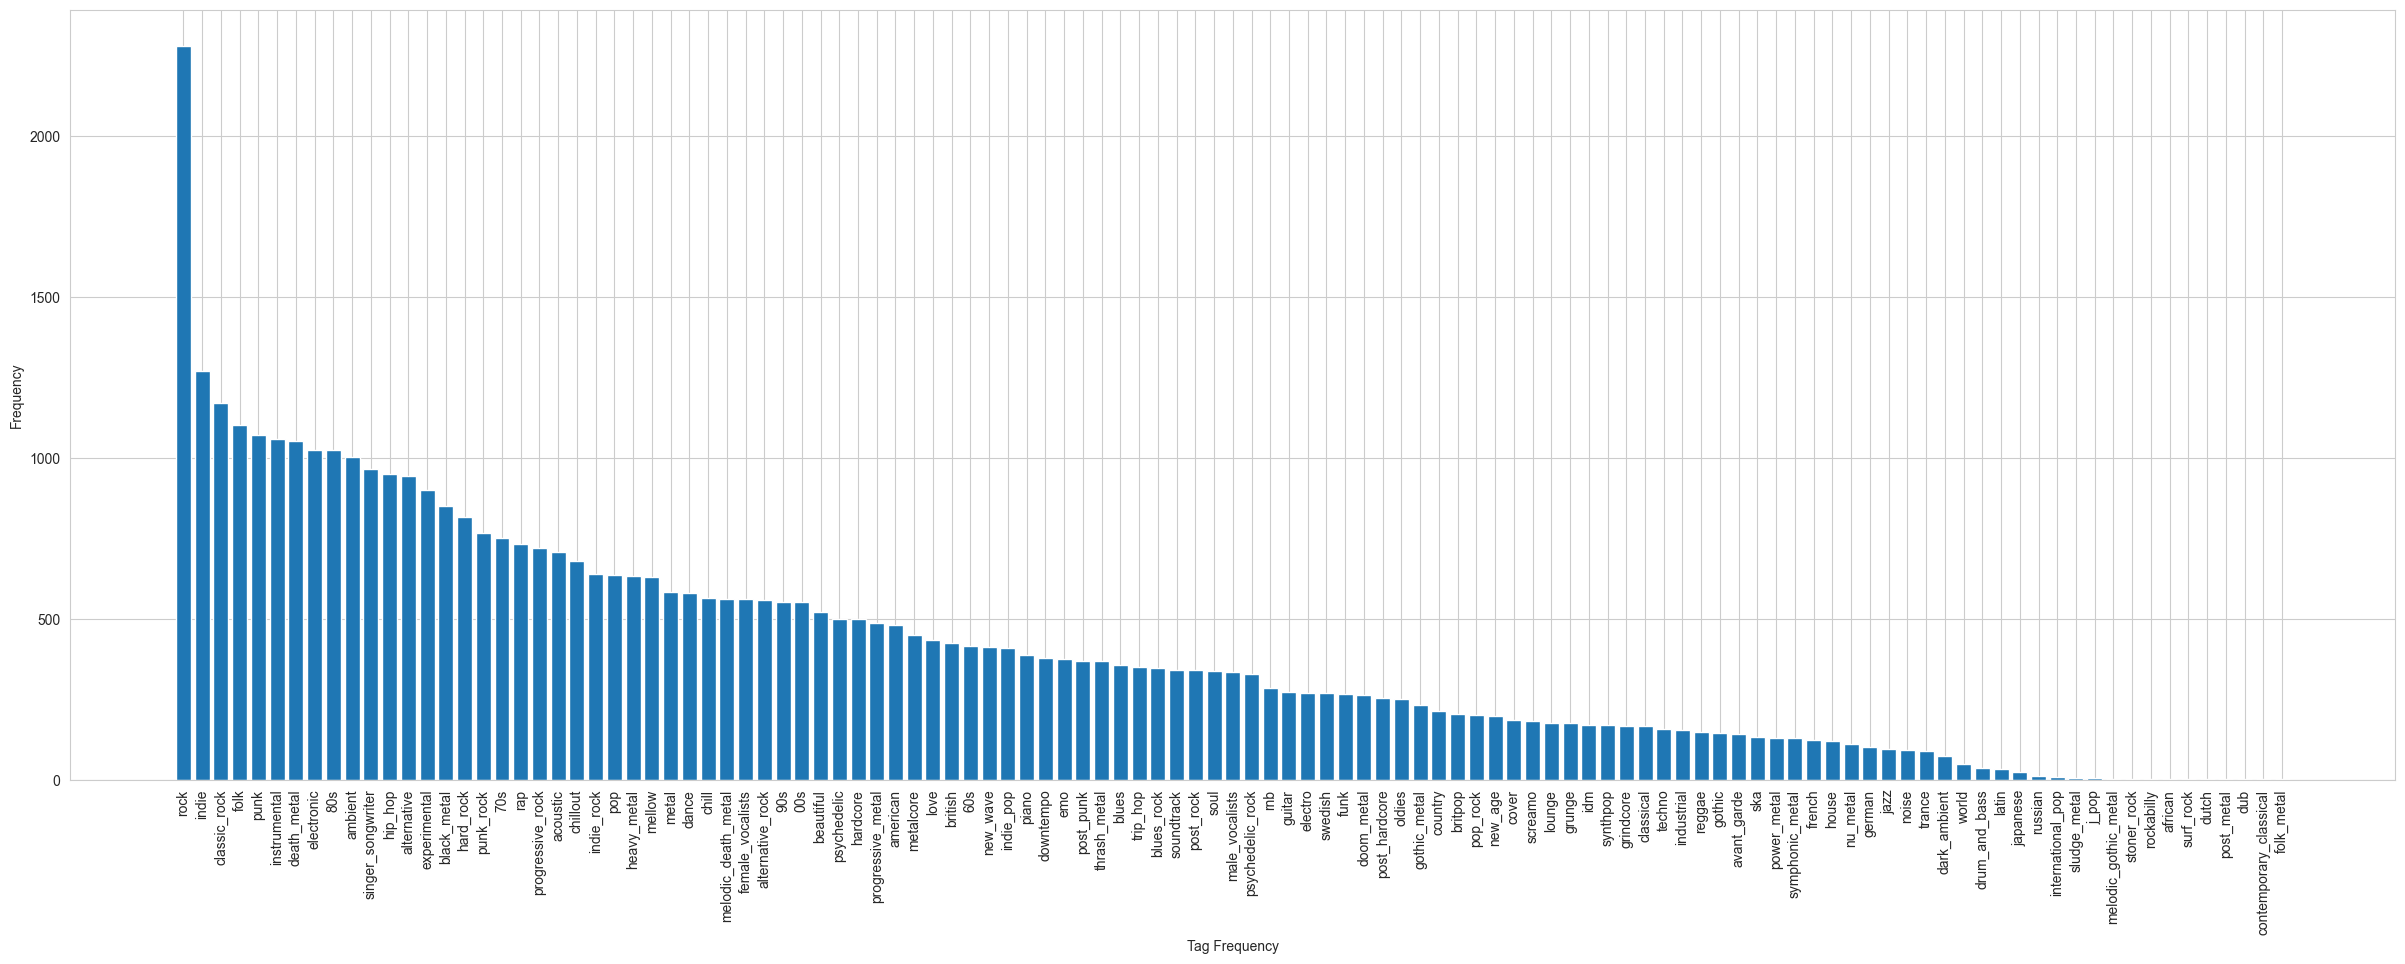

In [38]:
# ordered tag count histogram
plt.figure(figsize=(30,10))
plt.bar([tag[0] for tag in tag_counts.most_common()], [tag[1] for tag in tag_counts.most_common()])
plt.xlabel('Tag Frequency')
plt.xticks(rotation='vertical')
plt.ylabel('Frequency')
plt.show()

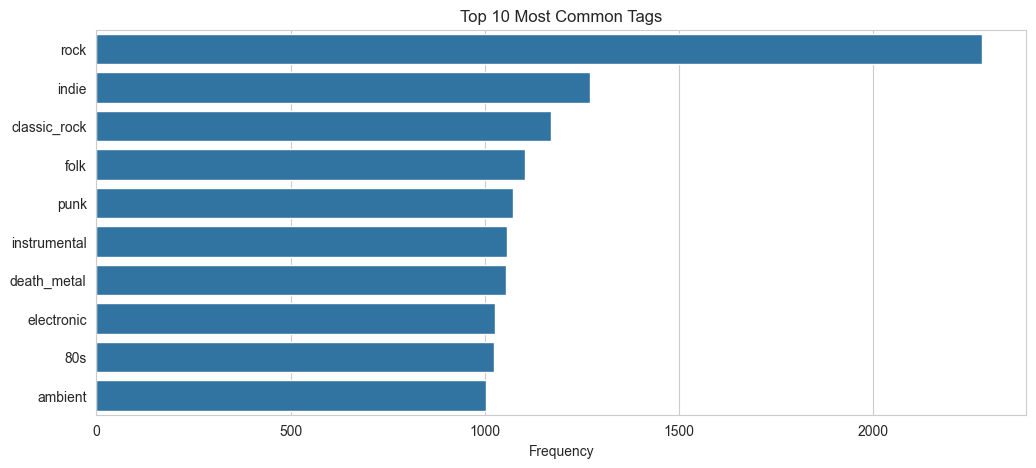

In [39]:
top_10_indices, top_10_values = zip(*tag_counts.most_common(10))
plt.figure(figsize=(12,5))
sns.barplot(data = pd.Series(top_10_values, index=top_10_indices), orient='h')
#plt.ylabel('Tag')
plt.xlabel('Frequency')
plt.title("Top 10 Most Common Tags")
plt.show()

### Task 2: Estimated genre distribution

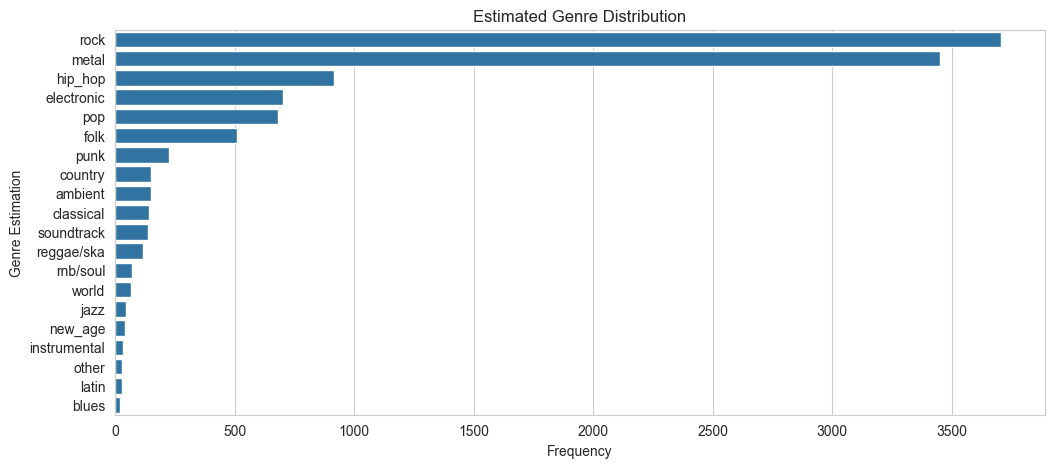

In [40]:
plt.figure(figsize=(12,5))
sns.barplot(data = df['crude_genre'].value_counts(), orient='h')
plt.ylabel('Genre Estimation')
plt.xlabel('Frequency')
plt.title("Estimated Genre Distribution")
plt.show()

In [41]:
df['crude_genre'].value_counts()

crude_genre
rock            3706
metal           3452
hip_hop          917
electronic       701
pop              681
folk             510
punk             227
country          152
ambient          150
classical        144
soundtrack       139
reggae/ska       116
rnb/soul          71
world             66
jazz              48
new_age           43
instrumental      33
other             31
latin             31
blues             21
Name: count, dtype: int64

The dataset is very rock/metal biased. What percentage is rock or metal? **Approximately 63.7% rock or metal.**

In [42]:
df['crude_genre'].value_counts()[:2].sum()/len(df)

np.float64(0.6368894029717946)

### Task 3. Year and Decade Distribution

The mean year is 2003 with standard deviation 9.6 years. The middle 50% of the dataset is between 2000 and 2009. 

In [43]:
df['year'].describe()

count    11239.000000
mean      2003.070914
std          9.647030
min       1933.000000
25%       2000.000000
50%       2006.000000
75%       2009.000000
max       2022.000000
Name: year, dtype: float64

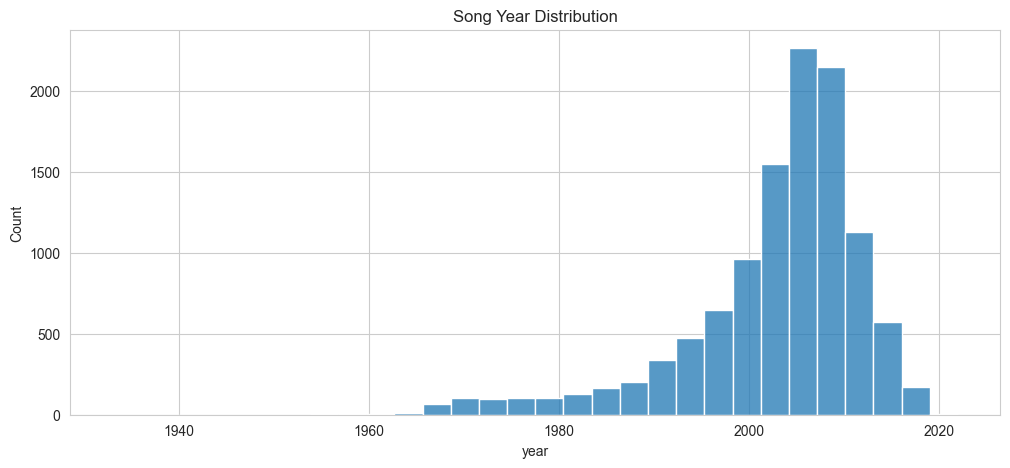

In [44]:
plt.figure(figsize=(12,5))
sns.histplot(df['year'], bins=30)
plt.title("Song Year Distribution")
plt.show()

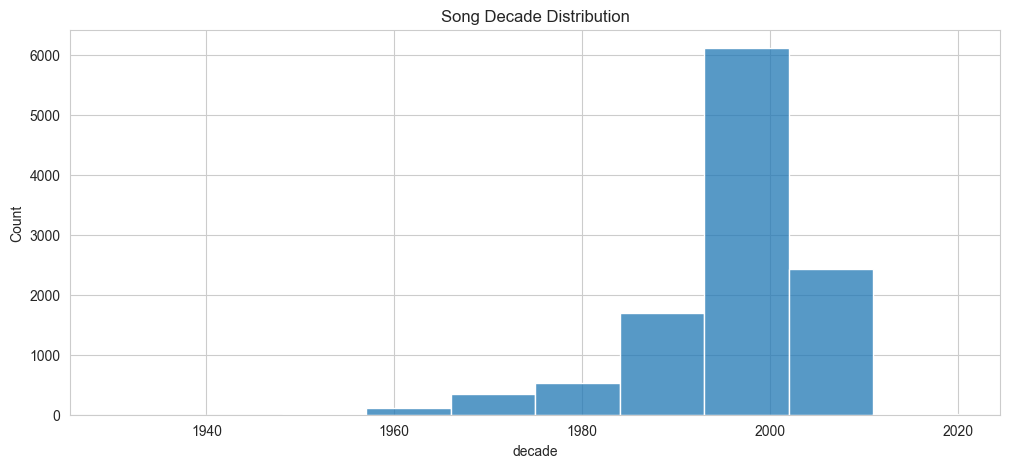

In [45]:
plt.figure(figsize=(12,5))
sns.histplot(df['decade'], bins=10)
plt.title("Song Decade Distribution")
plt.show()

In [46]:
df['decade'].value_counts()

decade
2000    6111
2010    2435
1990    1694
1980     528
1970     350
1960     108
2020       6
1950       6
1930       1
Name: count, dtype: int64

Approximately 76.0% of the tracks come from the decade 2000 or 2010.

In [47]:
df['decade'].value_counts()[:2].sum()/len(df)

np.float64(0.7603879348696503)

### Task 4: Artist analysis

In [48]:
artist_counts = Counter(df['artist'].str.lower().str.replace(' ',''))

In [49]:
# number of unique artists
len(artist_counts)

2881

In [50]:
# percentage of artists with more than 1 track in the dataframe
len([(artist, count) for artist, count in artist_counts.items() if count > 1]) / len(artist_counts)

0.5019090593543908

In [51]:
# percentage of artists with more than 2
len([(artist, count) for artist, count in artist_counts.items() if count > 2]) / len(artist_counts)

0.3554321416174939

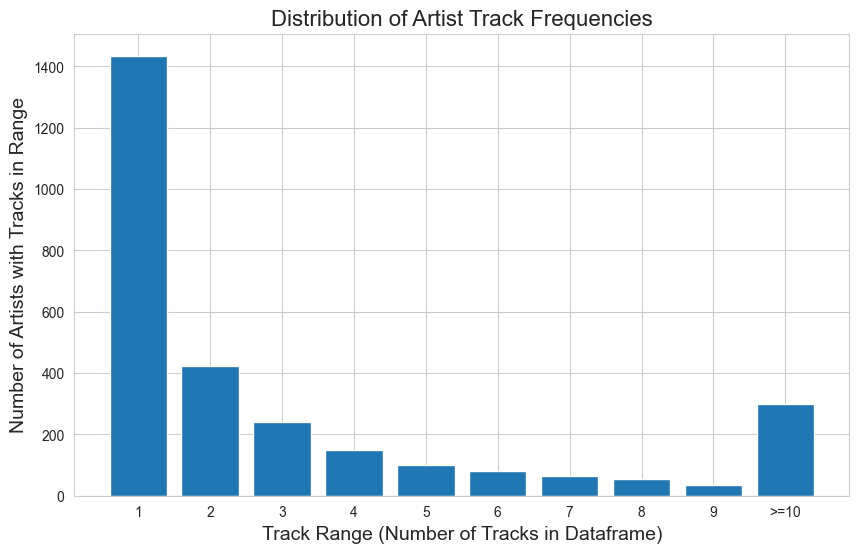

In [52]:
bin_counts = {str(i): 0 for i in range(1, 10)}
bin_counts['>=10'] = 0

for value in artist_counts.values():
    if value >= 10:
        bin_counts['>=10'] += 1
    elif 1 <= value <= 9:
        bin_counts[str(value)] += 1

labels = list(bin_counts.keys())
frequencies = list(bin_counts.values())

plt.figure(figsize=(10, 6))
plt.bar(labels, frequencies)
plt.xlabel("Track Range (Number of Tracks in Dataframe)", fontsize=14)
plt.ylabel("Number of Artists with Tracks in Range", fontsize=14)
plt.title("Distribution of Artist Track Frequencies", fontsize=16)

plt.show()

#### Verifying unique artists:

We verify that there are no duplicate artists due to characters in the string, e.g., additional spaces or special characters.

In [53]:
pattern = r'[^a-zA-Z0-9]'
# just special characters [^a-zA-Z0-9\s]
# special characters and spaces [^a-zA-Z0-9]

In [54]:
artist_df = df[['artist']].drop_duplicates()
artist_df['normalized_artist'] = df['artist'].str.lower().str.replace(pattern,'',regex = True)
artist_df

,artist,normalized_artist
0,Rush,rush
1,Queen,queen
2,Cream,cream
3,Creedence Clearwater Revival,creedenceclearwaterrevival
4,Lynyrd Skynyrd,lynyrdskynyrd
...,...,...
11229,Bing Crosby,bingcrosby
11230,Jimmy Durante,jimmydurante
11231,Carpenters,carpenters
11236,Feed Her to the Sharks,feedhertothesharks


In [55]:
for index, artist in artist_df['normalized_artist'].items():
    matches = artist_df.loc[artist_df['normalized_artist'] == artist]
    if len(matches) > 1:
        display(matches)

,artist,normalized_artist
5512,Արամ Խաչատրյան,
7242,!!!,
10912,倖田來未,
11172,عمر دياب,


,artist,normalized_artist
5512,Արամ Խաչատրյան,
7242,!!!,
10912,倖田來未,
11172,عمر دياب,


,artist,normalized_artist
5512,Արամ Խաչատրյան,
7242,!!!,
10912,倖田來未,
11172,عمر دياب,


,artist,normalized_artist
5512,Արամ Խաչատրյան,
7242,!!!,
10912,倖田來未,
11172,عمر دياب,


Special character only artists are being considered the same. Careful using regex.

In [56]:
artist_df = df[['artist']].drop_duplicates()
artist_df['normalized_artist'] = df['artist'].str.lower().str.replace(' ','')

for index, artist in artist_df['normalized_artist'].items():
    matches = artist_df.loc[artist_df['normalized_artist'] == artist]
    if len(matches) > 1:
        display(matches)

## Conclusion:

There is a strong bias in the tracks to rock or metal released between 2000 and 2020. 